# Focusing Cavity: Elliptical Mirror

Rebuilt from `legacy/Wave Equation.ipynb` through `wave_eq.py`, with the
corrected `cfl_dt` in place of the legacy diffusion-style `dt` formula.
A pulse launched from one focus of an elliptical cavity (Dirichlet walls)
should refocus at the other focus: the ellipse's defining reflection
property guarantees every reflected ray travels a *total* path length of
exactly `2a` (the major axis) from one focus to the other, regardless of
where it reflects -- so all the multiply-reflected wave contributions
arrive back at the second focus simultaneously, producing a sharp
amplitude spike there at `t = 2a/c`, well above the ordinary level of the
directly-spreading (unreflected) wave passing through earlier. That
predicted spike, not just a "does it look right" plot, is what's checked
here.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import wave_eq as w

os.makedirs('media', exist_ok=True)

In [2]:
NX, NY = 300, 300
dx = dy = 0.1
c = 1.0

x_idx, y_idx = np.meshgrid(np.arange(NX), np.arange(NY), indexing='ij')
center_x, center_y = NX // 2, NY // 2
ellipse_a = NX / 2.5   # semi-major axis, grid units
ellipse_b = NY / 3.5   # semi-minor axis, grid units
ellipse_mask = (((x_idx - center_x) / ellipse_a) ** 2 + ((y_idx - center_y) / ellipse_b) ** 2) <= 1

c_ellipse = np.sqrt(abs(ellipse_a**2 - ellipse_b**2))  # focal half-distance, grid units
left_focus = (center_x - c_ellipse, center_y)
right_focus = (center_x + c_ellipse, center_y)

a_phys = ellipse_a * dx
c_phys = c_ellipse * dx
t_focus_predicted = 2 * a_phys / c    # reflected-path refocusing time
t_direct_predicted = 2 * c_phys / c   # direct (unreflected) pass-through time
print(f'predicted refocus time = {t_focus_predicted:.2f}, direct pass-through time = {t_direct_predicted:.2f}')

X, Y = x_idx * dx, y_idx * dy
lf_x, lf_y = left_focus[0] * dx, left_focus[1] * dy
psi0 = 8 * np.exp(-((X - lf_x)**2 + (Y - lf_y)**2) / (2 * (NX * dx / 40)**2))
psi_curr, psi_prev = psi0.copy(), psi0.copy()

dt = w.cfl_dt(dx, dy, c, courant=0.4)
n_steps = int(1.3 * t_focus_predicted / dt)
print(f'dt={dt:.5f}, n_steps={n_steps}')

predicted refocus time = 24.00, direct pass-through time = 16.80
dt=0.02828, n_steps=1103


## Track amplitude at the second focus

observed peak time=24.81 (predicted 24.00), amplitude=5.503
amplitude during direct pass-through window: 0.625
refocus enhancement factor: 8.8x
PASS: the wave refocuses at the predicted time with a clear amplitude enhancement.


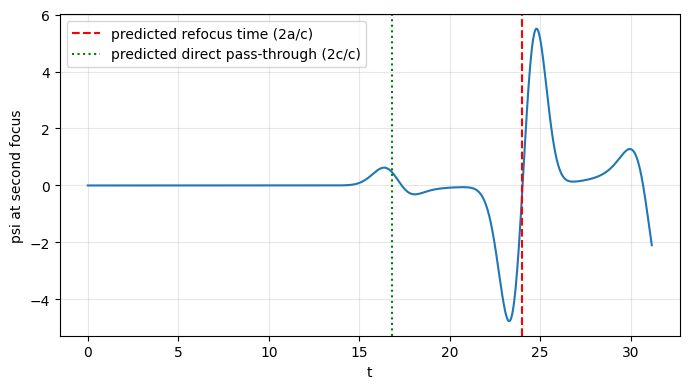

In [3]:
rf_i, rf_j = int(round(right_focus[0])), int(round(right_focus[1]))
record = np.zeros(n_steps)
frames = []
frame_stride = 15
for step in range(n_steps):
    psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c, mask=ellipse_mask)
    psi_prev, psi_curr = psi_curr, psi_next
    record[step] = psi_curr[rf_i, rf_j]
    if step % frame_stride == 0:
        frames.append(psi_curr.copy())

t_arr = np.arange(n_steps) * dt
peak_time = t_arr[np.argmax(np.abs(record))]
peak_amp = np.max(np.abs(record))

direct_window = (t_arr > t_direct_predicted - 1) & (t_arr < t_direct_predicted + 3)
direct_amp = np.max(np.abs(record[direct_window]))

print(f'observed peak time={peak_time:.2f} (predicted {t_focus_predicted:.2f}), amplitude={peak_amp:.3f}')
print(f'amplitude during direct pass-through window: {direct_amp:.3f}')
print(f'refocus enhancement factor: {peak_amp / direct_amp:.1f}x')

assert abs(peak_time - t_focus_predicted) / t_focus_predicted < 0.05, \
    'observed refocus time does not match the ellipse reflection-property prediction'
assert peak_amp > 5 * direct_amp, \
    'no clear refocusing enhancement over the ordinary direct-pass amplitude'
print('PASS: the wave refocuses at the predicted time with a clear amplitude enhancement.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_arr, record)
ax.axvline(t_focus_predicted, color='r', linestyle='--', label='predicted refocus time (2a/c)')
ax.axvline(t_direct_predicted, color='g', linestyle=':', label='predicted direct pass-through (2c/c)')
ax.set_xlabel('t'); ax.set_ylabel('psi at second focus'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/focusing_cavity_amplitude.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
vmax = np.max(np.abs(psi0))
im = ax.imshow(frames[0].T, cmap='seismic', origin='lower', extent=(0, NX * dx, 0, NY * dy),
               vmin=-vmax, vmax=vmax)
ax.plot(*[v * dx for v in left_focus], 'g+', markersize=12, label='foci')
ax.plot(*[v * dx for v in right_focus], 'g+', markersize=12)
ax.contour(ellipse_mask.T, levels=[0.5], colors='k', linewidths=1, extent=(0, NX * dx, 0, NY * dy))
ax.legend(loc='upper right')
time_text = ax.text(0.02, 0.96, '', color='k', transform=ax.transAxes)

def animate(i):
    im.set_array(frames[i].T)
    time_text.set_text(f't = {i * frame_stride * dt:.2f}')
    return im, time_text

ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=40, blit=True)
ani.save('media/focusing_cavity.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/focusing_cavity.mp4')

saved media/focusing_cavity.mp4
